# Supervised Learning with Quantum-Enhanced Feature Space

**Implementation of Havlicek *et al.*, Nature 567, 209–212 (2019)**

This notebook implements both classification strategies proposed in the paper:
1. **Quantum Kernel Estimator** — computes a quantum kernel matrix and feeds it to a classical SVM
2. **Quantum Variational Classifier** — trains a parametrized quantum circuit with classical optimization

Both methods encode classical data into quantum states via a **quantum feature map** $\mathcal{U}_{\Phi(\mathbf{x})}$, which maps data $\mathbf{x}$ to a quantum state $|\Phi(\mathbf{x})\rangle\langle\Phi(\mathbf{x})|$ in the Hilbert space. The key insight is that feature maps based on entangling gates at depth $d \geq 2$ are conjectured to be classically hard to simulate, potentially offering a quantum advantage.

---
## Part 0: Setup & Imports

In [37]:
# Core packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import functools
import warnings
import os

# Qiskit core
import qiskit
from qiskit.circuit import QuantumCircuit, Parameter, ParameterVector
from qiskit.circuit.library import ZZFeatureMap, ZFeatureMap, PauliFeatureMap
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit.primitives import StatevectorSampler

# Qiskit Aer
import qiskit_aer

# Qiskit Machine Learning
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.datasets import ad_hoc_data

# Qiskit Algorithms (optimizers)
from qiskit_machine_learning.optimizers import COBYLA, SPSA

# Scikit-learn utilities
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

warnings.filterwarnings('ignore', category=DeprecationWarning)
print("All imports successful.")

All imports successful.


💡 **Explanation:** This cell imports everything we need. Key packages:
- `qiskit` core + `qiskit_aer` for simulation
- `qiskit_machine_learning` provides `FidelityQuantumKernel` (modern kernel), `QSVC` (quantum SVM), `VQC` (variational classifier)
- `qiskit_machine_learning` also provides classical optimizers like `COBYLA` (must use this version for VQC callback compatibility)
- `StatevectorSampler` is the modern primitive for sampling quantum circuits
- `ComputeUncompute` computes state fidelity $|\langle\psi|\phi\rangle|^2$ via the "compute-uncompute" method
- We suppress `DeprecationWarning` because `ZZFeatureMap` class is deprecated in Qiskit 2.x in favor of the `zz_feature_map()` function, but the class still works and is more readable for this tutorial

In [ ]:
# # Version check
# print(f"Qiskit:              {qiskit.__version__}")
# print(f"Qiskit Aer:          {qiskit_aer.__version__}")
# import qiskit_machine_learning
# print(f"Qiskit ML:           {qiskit_machine_learning.__version__}")
# print(f"NumPy:               {np.__version__}")
# print(f"Pandas:              {pd.__version__}")

### Helper Functions

In [25]:
# --- Data loading helpers ---

DATA_DIR = os.path.join(os.getcwd(), "data")

def load_paper_csv(filepath):
    """Load one of the paper's CSV files. Columns are: index, feature_1, feature_2, Label (+1/-1).
    Returns X (n_samples, 2) and y (n_samples,) with labels as integers {+1, -1}."""
    df = pd.read_csv(filepath, header=0, index_col=0)
    # Columns are typically unnamed; assign names
    df.columns = ["feature_1", "feature_2", "label"] + list(df.columns[3:])
    df = df.dropna(how="all")
    X = df[["feature_1", "feature_2"]].values
    y = df["label"].values.astype(int)
    return X, y

def load_paper_classification(filepath):
    """Load a classification results CSV. Has extra columns: Test Result, Testing Success.
    Returns X, y_true, y_pred."""
    df = pd.read_csv(filepath, header=0, index_col=0)
    df.columns = ["feature_1", "feature_2", "label", "test_result"] + list(df.columns[4:])
    df = df.dropna(how="all")
    X = df[["feature_1", "feature_2"]].values
    y_true = df["label"].values.astype(int)
    y_pred = df["test_result"].values.astype(int)
    return X, y_true, y_pred

# --- Visualization helpers ---

def plot_kernel_matrix(kernel_matrix, title="Quantum Kernel Matrix"):
    """Plot a heatmap of the quantum kernel matrix."""
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(kernel_matrix, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Sample index")
    plt.colorbar(im, ax=ax, label="Fidelity")
    plt.tight_layout()
    plt.show()

def plot_decision_boundary(classifier, X, y, title="Decision Boundary", grid_steps=30):
    """Plot decision boundary for a 2D classifier (QSVC or VQC)."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_steps),
                         np.linspace(y_min, y_max, grid_steps))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = classifier.predict(grid_points)
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors="k", s=50)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Feature $x_1$")
    ax.set_ylabel("Feature $x_2$")
    plt.tight_layout()
    plt.show()

def plot_data(X, y, title="Dataset"):
    """Scatter plot of 2D data colored by label."""
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors="k", s=50)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Feature $x_1$")
    ax.set_ylabel("Feature $x_2$")
    plt.tight_layout()
    plt.show()

# --- Quantum kernel + QSVC pipeline helper ---

def build_qsvc(feature_map, X_train, y_train, X_test, y_test, plot_kernel=True, plot_boundary=True):
    """Build FidelityQuantumKernel + QSVC, fit, score, and optionally visualize."""
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler=sampler)
    qk = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

    # Compute and optionally display kernel matrix
    kernel_train = qk.evaluate(X_train)
    if plot_kernel:
        plot_kernel_matrix(kernel_train, title=f"Kernel Matrix ({feature_map.__class__.__name__})")

    qsvc = QSVC(quantum_kernel=qk)
    qsvc.fit(X_train, y_train)
    accuracy = qsvc.score(X_test, y_test)

    if plot_boundary:
        plot_decision_boundary(qsvc, X_train, y_train,
                               title=f"Decision Boundary — {feature_map.__class__.__name__} (acc={accuracy:.2f})")

    return qsvc, accuracy

print("Helper functions defined.")

Helper functions defined.


💡 **Explanation:** 
- `load_paper_csv` / `load_paper_classification`: The paper's CSV files have an unusual format — unnamed columns with an index column. These helpers parse them into clean `(X, y)` arrays. Labels are `+1`/`-1` strings that get converted to integers.
- `plot_kernel_matrix`: Visualizes the $n \times n$ quantum kernel matrix as a heatmap. Each entry $K_{ij} = |\langle\Phi(\mathbf{x}_i)|\Phi(\mathbf{x}_j)\rangle|^2$ measures how "similar" two data points are in the quantum feature space. A good kernel shows clear block structure (high similarity within class, low across classes).
- `plot_decision_boundary`: Creates a grid of points, classifies each, and plots the resulting regions. This shows how the classifier separates the two classes in 2D.
- `build_qsvc`: End-to-end helper that creates the `FidelityQuantumKernel` + `QSVC` pipeline, fits, scores, and visualizes. This saves us from repeating boilerplate code for each feature map experiment.

---
## Part 1: Quantum Feature Maps — Theory & Exploration

The quantum feature map is the core of both classification strategies in the paper. It nonlinearly maps a classical datum $\mathbf{x}$ to a quantum state $|\Phi(\mathbf{x})\rangle\langle\Phi(\mathbf{x})|$ in the Hilbert space. The unitary implementing this map is:

$$\mathcal{U}_{\Phi(\mathbf{x})} = \prod_d U_{\Phi(\mathbf{x})} H^{\otimes n}, \qquad U_{\Phi(\mathbf{x})} = \exp\left(i \sum_{S \subseteq [n]} \phi_S(\mathbf{x}) \prod_{k \in S} P_k\right)$$

where:
- $d$ is the circuit **depth** (number of repetitions)
- $n$ is the number of qubits (equals the data dimensionality)
- $S \subseteq [n]$ indexes subsets of qubits; $|S| \leq r$ gives the **expansion order** $r$
- $\phi_S(\mathbf{x})$ are **data map functions** encoding the classical data
- $P_k \in \{\mathbb{1}, X, Y, Z\}$ are Pauli operators on qubit $k$

The **second-order expansion** ($r=2$) with $P_k = Z$ and depth $d=2$ is the feature map used in the paper. It is conjectured to be classically hard to simulate, while the first-order ($r=1$) variant can be efficiently simulated classically.

### 1.0 Generate Synthetic Dataset

We use the `ad_hoc_data` function from `qiskit_machine_learning` to generate a synthetic 2D binary classification dataset. This data is generated using the second-order expansion feature map with default settings, so we expect a second-order feature map to classify it well.

Training samples: 40, Test samples: 20
Feature dimension: 2
Label values: [-1  1]


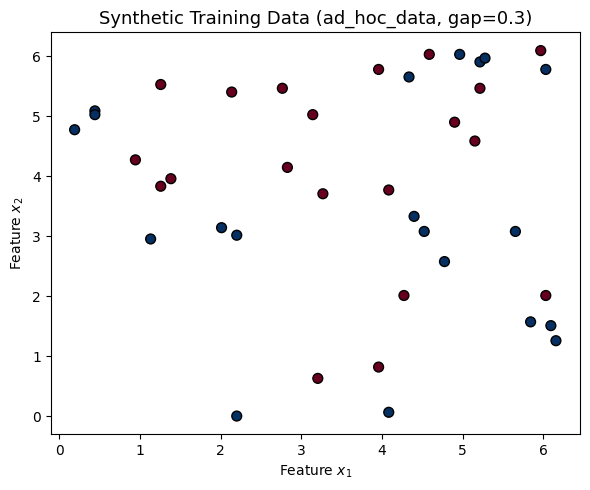

In [10]:
# Generate synthetic 2D classification data using the second-order expansion
feature_dim = 2
training_size = 20
test_size = 10

train_features, train_labels, test_features, test_labels = ad_hoc_data(
    training_size=training_size,
    test_size=test_size,
    n=feature_dim,
    gap=0.3,
    one_hot=False
)

# ad_hoc_data returns labels as 0/1; convert to +1/-1 to match paper convention
y_train = 2 * train_labels - 1
y_test = 2 * test_labels - 1

print(f"Training samples: {train_features.shape[0]}, Test samples: {test_features.shape[0]}")
print(f"Feature dimension: {train_features.shape[1]}")
print(f"Label values: {np.unique(y_train)}")

plot_data(train_features, y_train, title="Synthetic Training Data (ad_hoc_data, gap=0.3)")

💡 **Explanation:** The `ad_hoc_data` function generates a 2D binary classification dataset where the two classes are separated by a gap parameter. The data is specifically designed to be separable by a quantum feature map (second-order ZZ expansion). The `one_hot=False` flag gives us integer labels (0/1) instead of one-hot vectors. We convert to +1/-1 to match the paper's convention. The scatter plot shows the two classes — notice they form concentric-like clusters with a gap between them.

### 1.1 First-Order Expansion — ZFeatureMap

The `ZFeatureMap` implements a first-order diagonal expansion where $|S| = 1$. Each qubit is rotated by $R_Z(\phi_{\{i\}}(\mathbf{x})) = e^{i x_i Z_i}$ independently — there is **no entanglement** between qubits. Because the feature map is a product state, it can be efficiently simulated classically by uniform sampling (see Havlicek *et al.* Supplementary Information, Section IV). We expect poor classification accuracy on data designed for a second-order feature map.

ZFeatureMap circuit (depth=2):
     ┌───┐┌───────────┐┌───┐┌───────────┐
q_0: ┤ H ├┤ P(2*x[0]) ├┤ H ├┤ P(2*x[0]) ├
     ├───┤├───────────┤├───┤├───────────┤
q_1: ┤ H ├┤ P(2*x[1]) ├┤ H ├┤ P(2*x[1]) ├
     └───┘└───────────┘└───┘└───────────┘


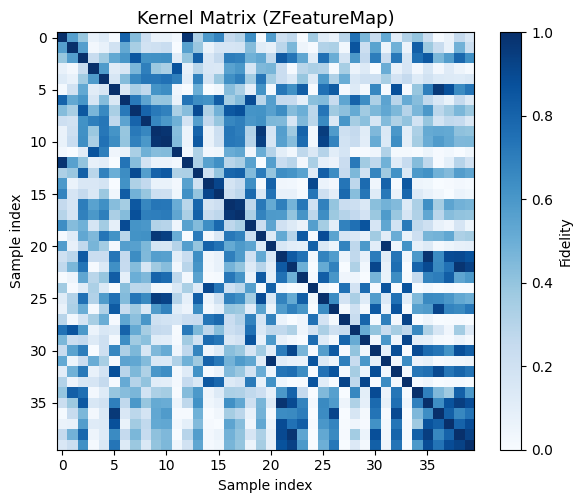

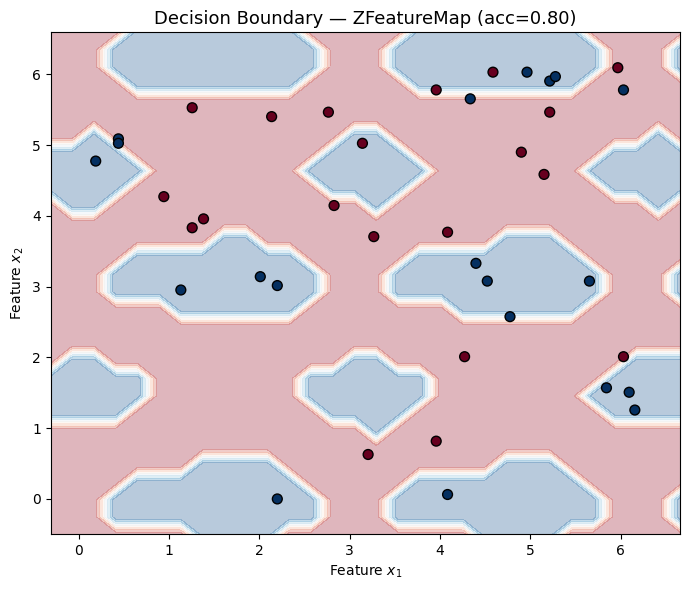


ZFeatureMap test accuracy: 0.8000


In [11]:
# 1.1 ZFeatureMap (first-order, no entanglement)
z_feature_map = ZFeatureMap(feature_dimension=feature_dim, reps=2)

print("ZFeatureMap circuit (depth=2):")
print(z_feature_map.decompose())

qsvc_z, acc_z = build_qsvc(z_feature_map, train_features, y_train, test_features, y_test)
print(f"\nZFeatureMap test accuracy: {acc_z:.4f}")

💡 **Explanation:** The ZFeatureMap applies only single-qubit $Z$ rotations — no two-qubit gates, no entanglement. The circuit printout shows only $H$ and $R_Z$ gates on each qubit independently. Because there's no interaction between features, the kernel cannot capture correlations between $x_1$ and $x_2$. The kernel matrix heatmap should show less block structure compared to the ZZFeatureMap, and the decision boundary should be less accurate at separating the two classes.

### 1.2 Second-Order Expansion — ZZFeatureMap

The `ZZFeatureMap` allows $|S| \leq 2$, encoding both single-qubit terms $\phi_{\{i\}}(\mathbf{x}) = x_i$ and two-qubit entangling terms $\phi_{\{i,j\}}(\mathbf{x}) = (\pi - x_i)(\pi - x_j)$. This is the feature map used in the paper. With depth $d=2$ and full entanglement, it is conjectured to be classically hard to simulate.

The default data map is:

$$\phi_S: \mathbf{x} \mapsto \begin{cases} x_i & \text{if } S = \{i\} \\ (\pi - x_i)(\pi - x_j) & \text{if } S = \{i, j\} \end{cases}$$

ZZFeatureMap circuit (depth=2, full entanglement):
     ┌───┐┌───────────┐                                        ┌───┐»
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──┤ H ├»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐├───┤»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├┤ H ├»
     └───┘└───────────┘└───┘└────────────────────────────┘└───┘└───┘»
«     ┌───────────┐                                        
«q_0: ┤ P(2*x[0]) ├──■──────────────────────────────────■──
«     ├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐
«q_1: ┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├
«     └───────────┘└───┘└────────────────────────────┘└───┘


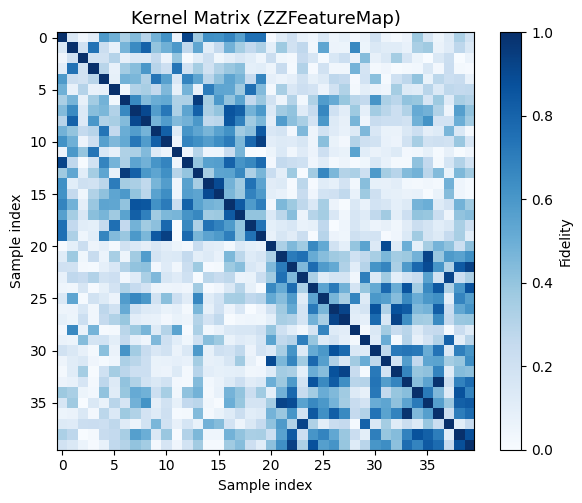

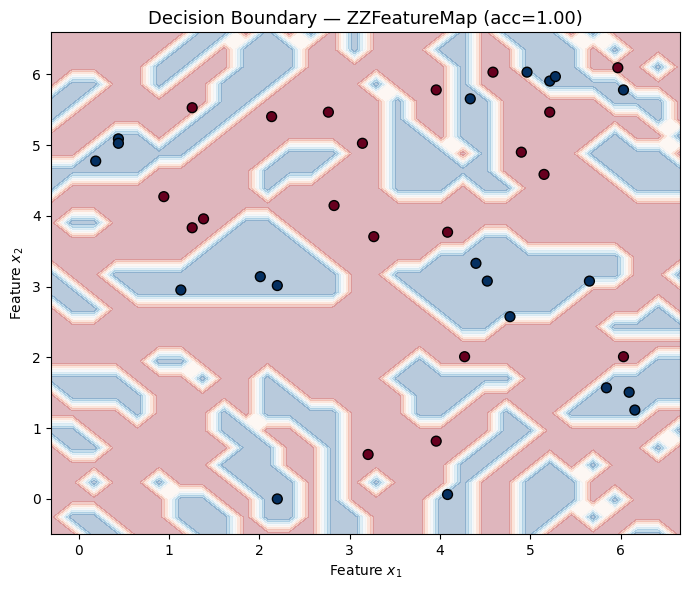


ZZFeatureMap test accuracy: 1.0000


In [12]:
# 1.2 ZZFeatureMap (second-order, default data map, full entanglement)
zz_feature_map = ZZFeatureMap(feature_dimension=feature_dim, reps=2, entanglement='full')

print("ZZFeatureMap circuit (depth=2, full entanglement):")
print(zz_feature_map.decompose())

qsvc_zz, acc_zz = build_qsvc(zz_feature_map, train_features, y_train, test_features, y_test)
print(f"\nZZFeatureMap test accuracy: {acc_zz:.4f}")

💡 **Explanation:** The ZZFeatureMap adds $ZZ$ entangling gates on top of the single-qubit $Z$ rotations. The `entanglement='full'` parameter means every pair of qubits gets an entangling gate — for 2 qubits that's just the pair (0,1). The circuit printout now shows CNOT gates implementing the $ZZ$ interaction. The kernel matrix should show strong block structure (high fidelity within each class, low across classes), and the decision boundary should cleanly separate the data. This is the feature map the paper argues provides a potential quantum advantage at depth $d \geq 2$.

### 1.3 Second-Order Expansion with Custom Data Map

Instead of the default $\phi_S$, we can define custom functions to encode classical data. We explore two variants:

1. **Product map:** $\phi_S: \mathbf{x} \mapsto \prod_{i \in S}(\pi - x_i)$ for $|S| > 1$
2. **Sin map:** $\phi_S: \mathbf{x} \mapsto \prod_{i \in S}\sin(\pi - x_i)$ for $|S| > 1$

Both introduce different nonlinearities in the encoding. The product map is similar to the default but without the single-element scaling, while the sin map adds periodic structure.

In [13]:
# 1.3a Custom data map: product of (pi - x_i)
def product_data_map_func(x):
    """phi_S(x) = x[0] if |S|=1, else product of (pi - x_i) for i in S."""
    coeff = x[0] if len(x) == 1 else functools.reduce(lambda m, n: m * n, np.pi - x)
    return coeff

# 1.3b Custom data map: product of sin(pi - x_i)
def sin_data_map_func(x):
    """phi_S(x) = x[0] if |S|=1, else product of sin(pi - x_i) for i in S."""
    coeff = x[0] if len(x) == 1 else functools.reduce(lambda m, n: m * n, np.sin(np.pi - x))
    return coeff

print("Custom data map functions defined.")

Custom data map functions defined.


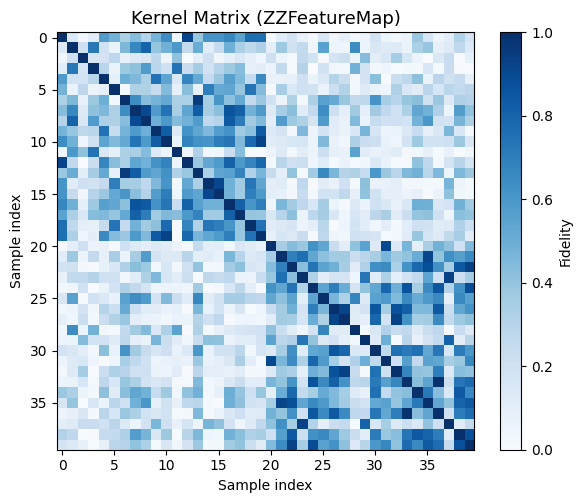

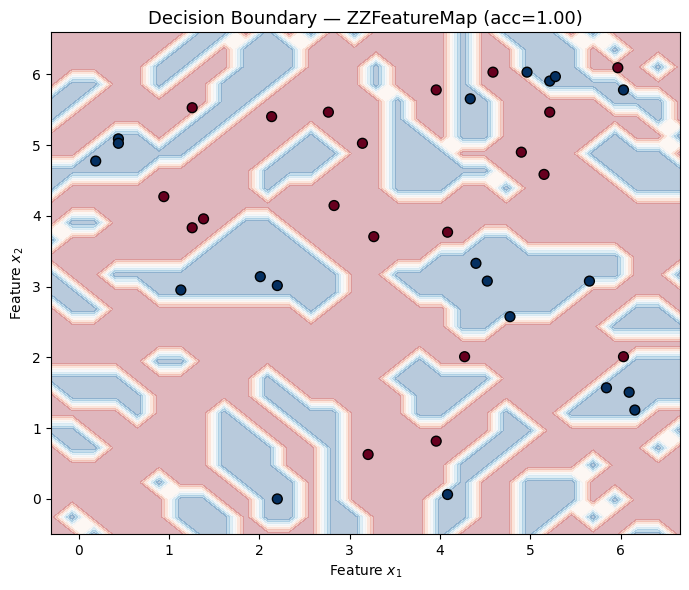

ZZFeatureMap (product map) test accuracy: 1.0000


In [14]:
# 1.3a ZZFeatureMap with product data map
zz_product_map = ZZFeatureMap(feature_dimension=feature_dim, reps=2, data_map_func=product_data_map_func)

qsvc_zz_prod, acc_zz_prod = build_qsvc(zz_product_map, train_features, y_train, test_features, y_test)
print(f"ZZFeatureMap (product map) test accuracy: {acc_zz_prod:.4f}")

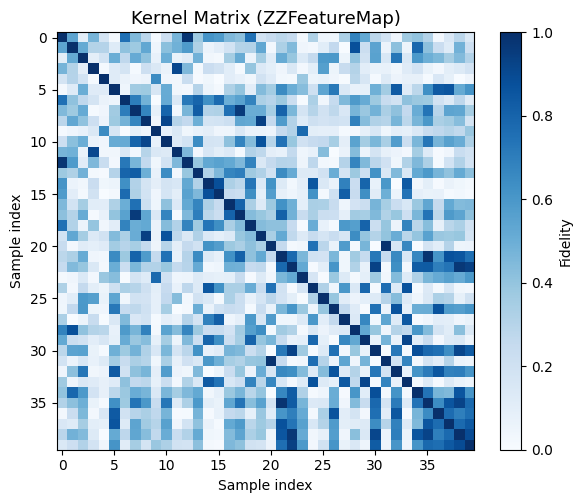

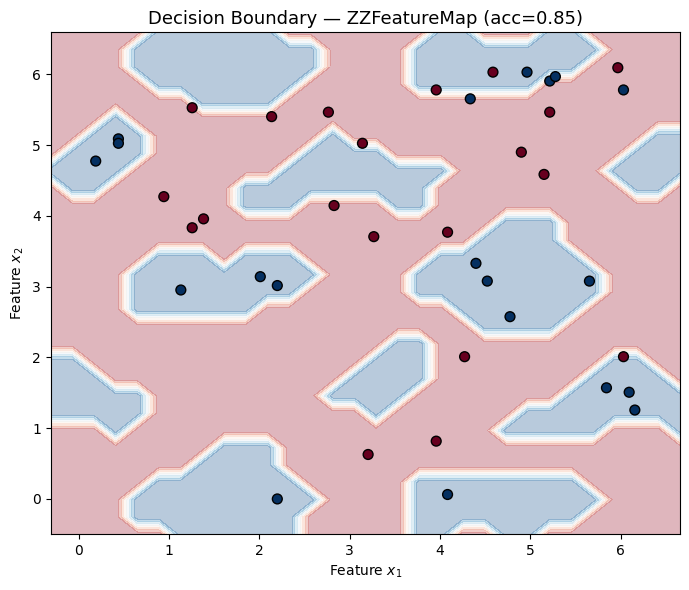

ZZFeatureMap (sin map) test accuracy: 0.8500


In [15]:
# 1.3b ZZFeatureMap with sin data map
zz_sin_map = ZZFeatureMap(feature_dimension=feature_dim, reps=2, data_map_func=sin_data_map_func)

qsvc_zz_sin, acc_zz_sin = build_qsvc(zz_sin_map, train_features, y_train, test_features, y_test)
print(f"ZZFeatureMap (sin map) test accuracy: {acc_zz_sin:.4f}")

💡 **Explanation:** The custom data map functions change how classical data is encoded into the rotation angles of the quantum gates. The default map uses $(\pi - x_i)(\pi - x_j)$ for pair terms, while our product map uses the same formula but is explicitly defined, and the sin map introduces $\sin(\pi - x_i)\sin(\pi - x_j)$. The sin variant adds periodic structure which may help or hurt depending on the data distribution. Compare the kernel matrices and accuracies — the default map should perform best since the synthetic data was generated using it.

### 1.4 Second-Order Pauli Expansion

The `PauliFeatureMap` generalizes the feature map by allowing arbitrary Pauli gate sets. Instead of only $Z$ and $ZZ$ gates, we can use $Y$, $X$, or mixed gates like $ZZ$, $YY$, $XY$. With `paulis=['Z','Y','ZZ']`, the feature map becomes:

$$\mathcal{U}_{\Phi(\mathbf{x})} = \left( \exp\left(i\sum_{jk} \phi_{\{j,k\}} Z_j \otimes Z_k\right) \exp\left(i\sum_j \phi_{\{j\}} Y_j\right) \exp\left(i\sum_j \phi_{\{j\}} Z_j\right) H^{\otimes n} \right)^d$$

This adds a layer of $Y$-rotations alongside the $Z$-rotations, increasing expressivity but also circuit complexity.

PauliFeatureMap ['Z','Y','ZZ'] circuit:
     ┌───┐┌───────────┐┌────┐┌───────────┐┌──────┐     »
q_0: ┤ H ├┤ P(2*x[0]) ├┤ √X ├┤ P(2*x[0]) ├┤ √Xdg ├──■──»
     ├───┤├───────────┤├────┤├───────────┤├──────┤┌─┴─┐»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ √X ├┤ P(2*x[1]) ├┤ √Xdg ├┤ X ├»
     └───┘└───────────┘└────┘└───────────┘└──────┘└───┘»
«                                        ┌───┐┌───────────┐┌────┐┌───────────┐»
«q_0: ────────────────────────────────■──┤ H ├┤ P(2*x[0]) ├┤ √X ├┤ P(2*x[0]) ├»
«     ┌────────────────────────────┐┌─┴─┐├───┤├───────────┤├────┤├───────────┤»
«q_1: ┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├┤ H ├┤ P(2*x[1]) ├┤ √X ├┤ P(2*x[1]) ├»
«     └────────────────────────────┘└───┘└───┘└───────────┘└────┘└───────────┘»
«     ┌──────┐                                        
«q_0: ┤ √Xdg ├──■──────────────────────────────────■──
«     ├──────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐
«q_1: ┤ √Xdg ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├
«     └──────┘└───┘└────────────────────────────┘└───┘


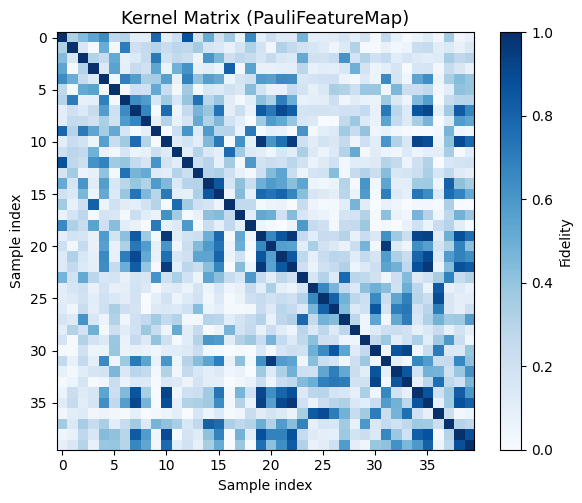

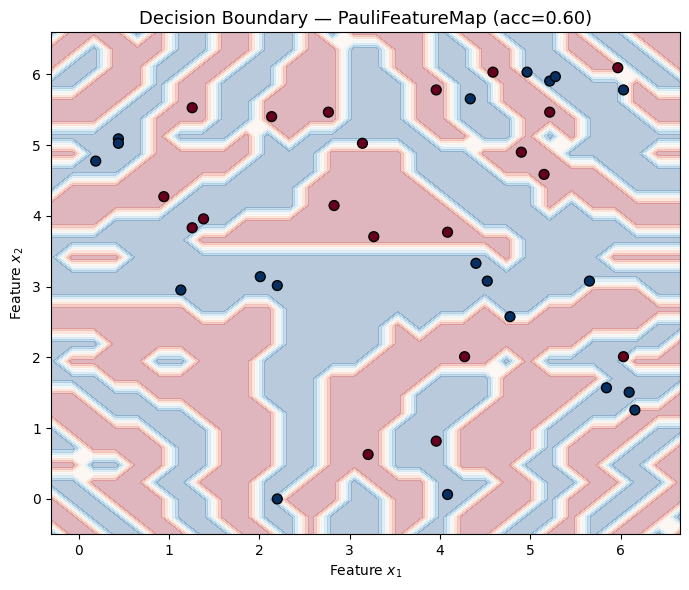


PauliFeatureMap ['Z','Y','ZZ'] test accuracy: 0.6000


In [16]:
# 1.4 PauliFeatureMap with paulis=['Z','Y','ZZ']
pauli_map_zyz = PauliFeatureMap(feature_dimension=feature_dim, reps=2, paulis=['Z', 'Y', 'ZZ'])

print("PauliFeatureMap ['Z','Y','ZZ'] circuit:")
print(pauli_map_zyz.decompose())

qsvc_pauli_zyz, acc_pauli_zyz = build_qsvc(pauli_map_zyz, train_features, y_train, test_features, y_test)
print(f"\nPauliFeatureMap ['Z','Y','ZZ'] test accuracy: {acc_pauli_zyz:.4f}")

💡 **Explanation:** The `PauliFeatureMap` with `paulis=['Z','Y','ZZ']` adds a $Y$-rotation layer between the $Z$-rotation and $ZZ$-entangling layers. This means each qubit is rotated around both the $Z$ and $Y$ axes, creating a richer encoding. However, more gates don't always mean better accuracy — the extra expressiveness may not match the data distribution. The circuit printout will show additional $R_Y$ gates. The accuracy may be lower than the pure ZZFeatureMap on this synthetic data.

### 1.5 Third-Order Pauli Expansion

Higher-order expansions ($|S| \leq r$ with $r \geq 3$) encode interactions among three or more features simultaneously. With `paulis=['Y','Z','ZZ','ZZZ']` on 3D data, the feature map includes three-qubit entangling terms $\phi_{\{i,j,k\}}(\mathbf{x}) \prod_{l \in \{i,j,k\}} Z_l$. This increases expressivity but also circuit depth and noise susceptibility on real hardware.

PauliFeatureMap ['Y','Z','ZZ','ZZZ'] on 3D data:
  Qubits: 3
  Depth:  38


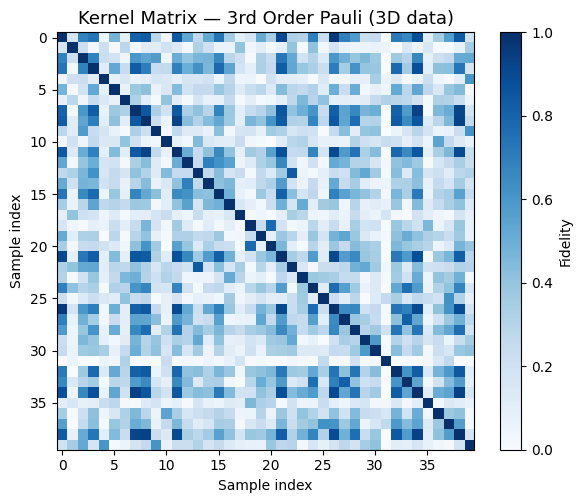

3rd Order PauliFeatureMap test accuracy: 0.5500


In [17]:
# 1.5 Third-order Pauli expansion on 3D data
feature_dim_3 = 3
train_features_3d, train_labels_3d, test_features_3d, test_labels_3d = ad_hoc_data(
    training_size=20, test_size=10, n=feature_dim_3, gap=0.3, one_hot=False
)
y_train_3d = 2 * train_labels_3d - 1
y_test_3d = 2 * test_labels_3d - 1

pauli_map_3rd = PauliFeatureMap(
    feature_dimension=feature_dim_3, reps=2,
    paulis=['Y', 'Z', 'ZZ', 'ZZZ'],
    data_map_func=product_data_map_func
)

print(f"PauliFeatureMap ['Y','Z','ZZ','ZZZ'] on 3D data:")
print(f"  Qubits: {pauli_map_3rd.num_qubits}")
print(f"  Depth:  {pauli_map_3rd.decompose().depth()}")

# Use the pipeline (no decision boundary for 3D data)
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)
qk_3rd = FidelityQuantumKernel(feature_map=pauli_map_3rd, fidelity=fidelity)
kernel_3rd = qk_3rd.evaluate(train_features_3d)
plot_kernel_matrix(kernel_3rd, title="Kernel Matrix — 3rd Order Pauli (3D data)")

qsvc_3rd = QSVC(quantum_kernel=qk_3rd)
qsvc_3rd.fit(train_features_3d, y_train_3d)
acc_3rd = qsvc_3rd.score(test_features_3d, y_test_3d)
print(f"3rd Order PauliFeatureMap test accuracy: {acc_3rd:.4f}")

💡 **Explanation:** For 3D data we need 3 qubits. The `paulis=['Y','Z','ZZ','ZZZ']` parameter creates a feature map with four layers per repetition: single-qubit $Y$ rotations, single-qubit $Z$ rotations, two-qubit $ZZ$ entangling gates (for all pairs: (0,1), (1,2), (0,2)), and three-qubit $ZZZ$ entangling gate. The `data_map_func=product_data_map_func` applies our custom product encoding. We skip the decision boundary plot since 3D data can't be easily visualized in 2D. The kernel matrix should still show block structure if the feature map captures the data's structure well.

### 1.6 Custom Feature Map — RX + ZZ Layers

Beyond the built-in feature maps, we can construct entirely custom circuits. Below we build a feature map with alternating layers of $R_X$ single-qubit gates and $ZZ$ two-qubit entangling gates. This is not part of the standard `PauliFeatureMap` family and demonstrates how to create a pluggable custom feature map compatible with the modern Qiskit ML pipeline.

The circuit for depth $d$ consists of $d$ repetitions of:
1. $R_X(x_i)$ on each qubit $i$
2. CNOT–$R_Z(x_i \cdot x_j)$–CNOT entangling block for each qubit pair $(i, j)$

Custom RX+ZZ feature map circuit:
     ┌──────────┐                           ┌──────────┐                      »
q_0: ┤ Rx(x[0]) ├──■─────────────────────■──┤ Rx(x[0]) ├──■───────────────────»
     ├──────────┤┌─┴─┐┌───────────────┐┌─┴─┐├──────────┤┌─┴─┐┌───────────────┐»
q_1: ┤ Rx(x[1]) ├┤ X ├┤ Rz(x[0]*x[1]) ├┤ X ├┤ Rx(x[1]) ├┤ X ├┤ Rz(x[0]*x[1]) ├»
     └──────────┘└───┘└───────────────┘└───┘└──────────┘└───┘└───────────────┘»
«          
«q_0: ──■──
«     ┌─┴─┐
«q_1: ┤ X ├
«     └───┘


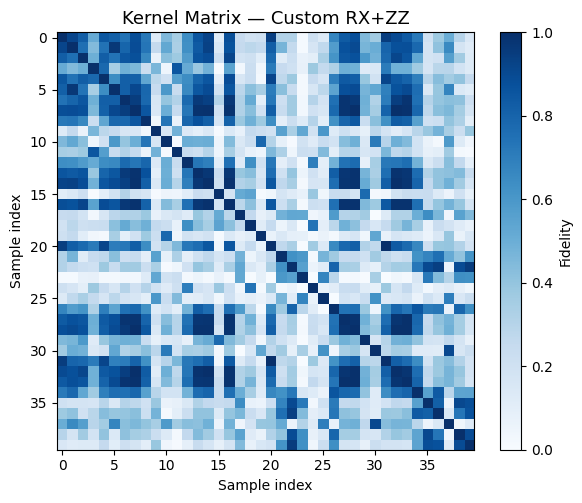

Custom RX+ZZ feature map test accuracy: 0.7000


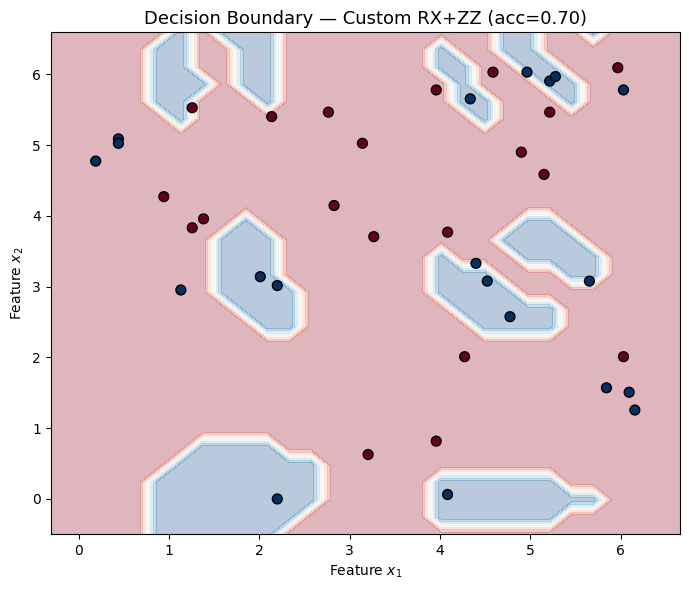

In [18]:
# 1.6 Custom feature map: RX + ZZ layers
# Build a QuantumCircuit that is compatible with FidelityQuantumKernel

def build_custom_rx_zz_circuit(num_qubits, depth=2):
    """Build a custom feature map circuit with RX + ZZ layers.
    Returns a QuantumCircuit with ParameterVector for data binding."""
    x = ParameterVector("x", num_qubits)
    qc = QuantumCircuit(num_qubits)

    for _ in range(depth):
        # Layer 1: RX rotations encoding each feature
        for i in range(num_qubits):
            qc.rx(x[i], i)

        # Layer 2: ZZ entangling blocks for each pair
        for i in range(num_qubits):
            for j in range(i + 1, num_qubits):
                qc.cx(i, j)
                qc.rz(x[i] * x[j], j)
                qc.cx(i, j)

    return qc

custom_fm = build_custom_rx_zz_circuit(num_qubits=feature_dim, depth=2)
print("Custom RX+ZZ feature map circuit:")
print(custom_fm.draw())

# Test with the QSVC pipeline
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)
qk_custom = FidelityQuantumKernel(feature_map=custom_fm, fidelity=fidelity)
kernel_custom = qk_custom.evaluate(train_features)
plot_kernel_matrix(kernel_custom, title="Kernel Matrix — Custom RX+ZZ")

qsvc_custom = QSVC(quantum_kernel=qk_custom)
qsvc_custom.fit(train_features, y_train)
acc_custom = qsvc_custom.score(test_features, y_test)
print(f"Custom RX+ZZ feature map test accuracy: {acc_custom:.4f}")

plot_decision_boundary(qsvc_custom, train_features, y_train,
                       title=f"Decision Boundary — Custom RX+ZZ (acc={acc_custom:.2f})")

💡 **Explanation:** Instead of using a built-in feature map class, we construct a `QuantumCircuit` directly with `ParameterVector` for the data. The `ParameterVector("x", num_qubits)` creates symbolic parameters `x[0], x[1], ...` that get bound to actual data values when the circuit is executed. The custom map uses $R_X$ gates (rotations around the X-axis) instead of $R_Z$, and the entangling block uses CNOT–$R_Z$–CNOT to implement a $ZZ$ interaction. This circuit is fully compatible with `FidelityQuantumKernel` — any `QuantumCircuit` with unbound parameters works. The accuracy may differ from `ZZFeatureMap` because $R_X$ encodes data differently than $R_Z$.

### 1.7 Feature Map Comparison Summary

Feature Map                           Accuracy
ZFeatureMap (1st order)                 0.8000
ZZFeatureMap (2nd order, default)       1.0000
ZZFeatureMap (product map)              1.0000
ZZFeatureMap (sin map)                  0.8500
PauliFeatureMap [Z,Y,ZZ]                0.6000
Custom RX+ZZ                            0.7000


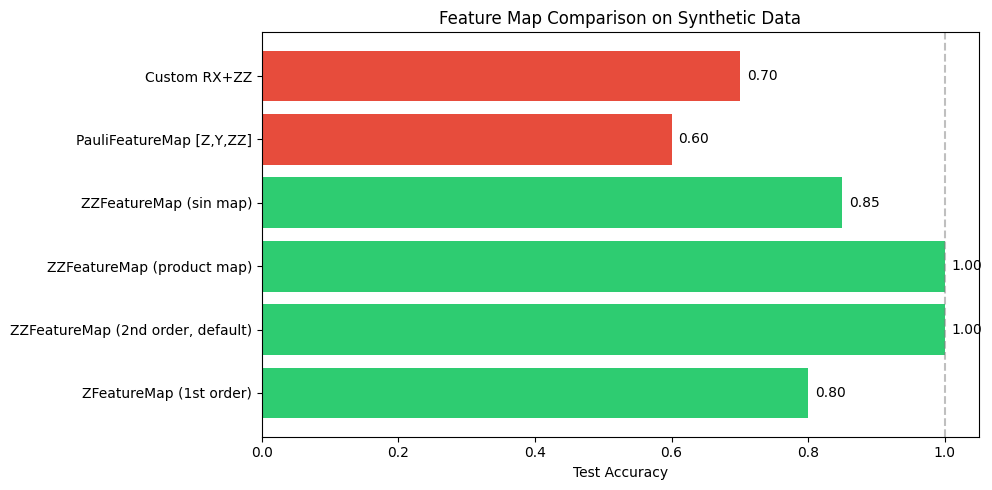

In [19]:
# Summary comparison of all feature maps on synthetic 2D data
results = {
    "ZFeatureMap (1st order)": acc_z,
    "ZZFeatureMap (2nd order, default)": acc_zz,
    "ZZFeatureMap (product map)": acc_zz_prod,
    "ZZFeatureMap (sin map)": acc_zz_sin,
    "PauliFeatureMap [Z,Y,ZZ]": acc_pauli_zyz,
    "Custom RX+ZZ": acc_custom,
}

print("=" * 55)
print(f"{'Feature Map':<35} {'Accuracy':>10}")
print("=" * 55)
for name, acc in results.items():
    print(f"{name:<35} {acc:>10.4f}")
print("=" * 55)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
accs = list(results.values())
bars = ax.barh(names, accs, color=['#e74c3c' if a < 0.8 else '#2ecc71' for a in accs])
ax.set_xlim(0, 1.05)
ax.set_xlabel("Test Accuracy")
ax.set_title("Feature Map Comparison on Synthetic Data")
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{acc:.2f}", va='center')
plt.tight_layout()
plt.show()

💡 **Explanation:** This summary compares all feature maps tested on the same synthetic dataset. Key observations to expect:
- **ZZFeatureMap (default)** should achieve the highest accuracy since the data was generated using this exact feature map
- **ZFeatureMap** should perform poorly — no entanglement means it can't capture feature correlations
- **Custom maps** may perform reasonably but not as well as the matched default map
- The bar chart gives a quick visual comparison — green bars (≥0.8 accuracy) vs red bars (<0.8)

This confirms the paper's central claim: the choice of feature map matters, and entanglement (second-order terms) is essential for capturing nonlinear data structure.

---
## Part 2: Quantum Kernel Estimator — Direct Kernel Method

The Quantum Kernel Estimator computes the kernel matrix $K_{ij} = |\langle\Phi(\mathbf{x}_i)|\Phi(\mathbf{x}_j)\rangle|^2$ using a quantum circuit, then feeds this matrix into a classical support vector machine (SVM). The quantum advantage comes from the feature map: if $\mathcal{U}_{\Phi(\mathbf{x})}$ is hard to simulate classically, then the kernel $K$ encodes correlations that are classically intractable to compute.

The algorithm proceeds as follows:
1. For each pair $(\mathbf{x}_i, \mathbf{x}_j)$ in the training set, compute $K_{ij}$ by running the "compute-uncompute" circuit: prepare $|\Phi(\mathbf{x}_i)\rangle$ and $|\Phi(\mathbf{x}_j)\rangle$ on separate registers, then measure the swap-like fidelity
2. Use $K$ as a precomputed kernel for a classical SVM (e.g., `QSVC` in Qiskit ML)
3. For prediction, compute kernel values between test points and training points, then apply the SVM decision function

We now apply this method to the **actual datasets from the paper** (Sets I, II, III).

### 2.1 Load Paper Datasets

The paper provides three dataset splits (Sets I, II, III) for the kernel method, each with 20 training samples (10 per class) and test samples. The data lives in the `data/` directory.

Set I: train=40 samples, test=440 samples, paper reported accuracy=1.0000
Set II: train=40 samples, test=400 samples, paper reported accuracy=1.0000
Set III: train=40 samples, test=400 samples, paper reported accuracy=0.9475


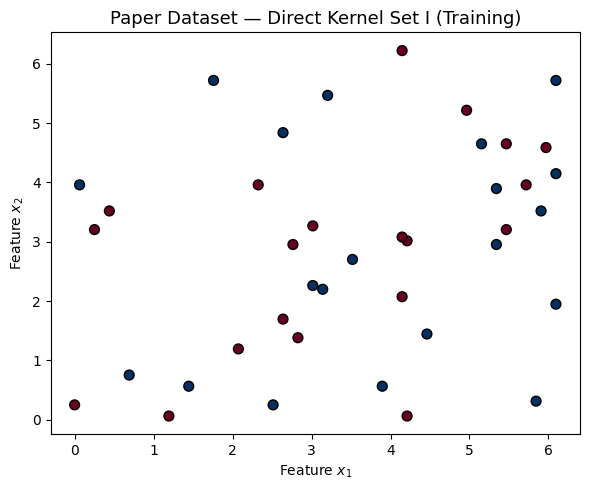

In [26]:
# 2.1 Load the three dataset splits for the Direct Kernel method
kernel_sets = {}
for set_name in ["I", "II", "III"]:
    train_path = os.path.join(DATA_DIR, f"Direct_Kernel_Set_{set_name}_Training.csv")
    test_path = os.path.join(DATA_DIR, f"Direct_Kernel_Set_{set_name}_Classifications_ResultsOnly.csv")
    
    X_train, y_train = load_paper_csv(train_path)
    X_test, y_true, y_pred_paper = load_paper_classification(test_path)
    
    kernel_sets[set_name] = {
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_true, "y_pred_paper": y_pred_paper
    }
    
    paper_acc = accuracy_score(y_true, y_pred_paper)
    print(f"Set {set_name}: train={X_train.shape[0]} samples, test={X_test.shape[0]} samples, "
          f"paper reported accuracy={paper_acc:.4f}")

# Visualize one of the training sets
plot_data(kernel_sets["I"]["X_train"], kernel_sets["I"]["y_train"],
          title="Paper Dataset — Direct Kernel Set I (Training)")

💡 **Explanation:** The paper provides three different random splits of the same classification problem. Each split has 20 training points (10 per class) and test points with ground truth labels and the paper's own predictions. We load both training and test data, and also extract the paper's reported predictions (`y_pred_paper`) so we can compare our implementation against the paper's results. The scatter plot shows the training data — notice the data points are in the range [0, 2π] which matches the paper's convention.

### 2.2 Quantum Kernel Estimation on Paper Data

We now compute the quantum kernel using `ZZFeatureMap` with depth $d=2$ (the paper's configuration) and train `QSVC` on each dataset split.

Set I: Our QSVC accuracy = 1.0000, Paper accuracy = 1.0000
Set II: Our QSVC accuracy = 0.9975, Paper accuracy = 1.0000
Set III: Our QSVC accuracy = 0.9900, Paper accuracy = 0.9475


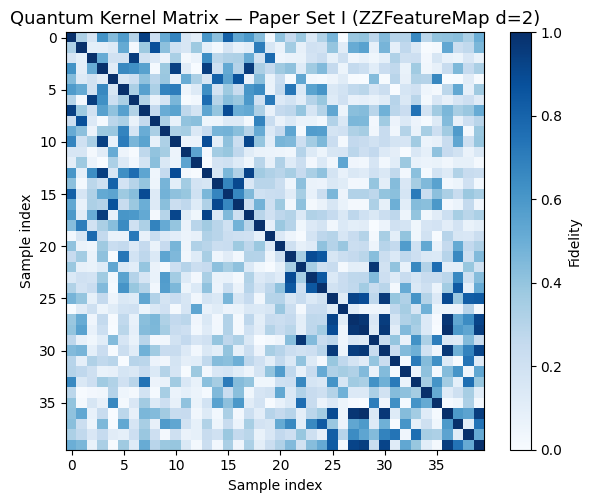

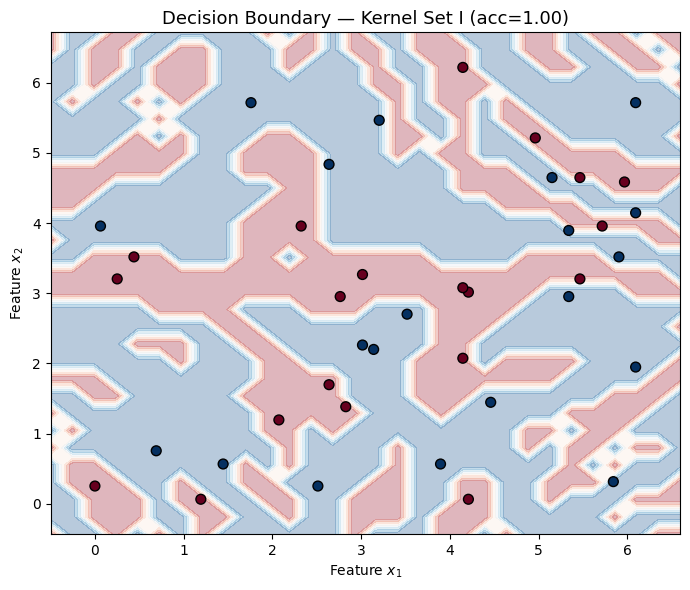

In [28]:
# 2.2 Quantum Kernel Estimation on paper data using ZZFeatureMap (d=2)
zz_kernel_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='full')

sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)
qk = FidelityQuantumKernel(feature_map=zz_kernel_map, fidelity=fidelity)

kernel_results = {}
for set_name in ["I", "II", "III"]:
    data = kernel_sets[set_name]
    X_train, y_train = data["X_train"], data["y_train"]
    X_test, y_test = data["X_test"], data["y_test"]
    
    # Compute kernel matrices
    kernel_train = qk.evaluate(X_train)
    kernel_test = qk.evaluate(X_test, X_train)
    
    # Train QSVC
    qsvc = QSVC(quantum_kernel=qk)
    qsvc.fit(X_train, y_train)
    our_acc = qsvc.score(X_test, y_test)
    paper_acc = accuracy_score(y_test, data["y_pred_paper"])
    
    kernel_results[set_name] = {
        "our_accuracy": our_acc,
        "paper_accuracy": paper_acc,
        "qsvc": qsvc,
        "kernel_train": kernel_train
    }
    
    print(f"Set {set_name}: Our QSVC accuracy = {our_acc:.4f}, Paper accuracy = {paper_acc:.4f}")

# Visualize kernel matrix for Set I
plot_kernel_matrix(kernel_results["I"]["kernel_train"],
                   title="Quantum Kernel Matrix — Paper Set I (ZZFeatureMap d=2)")

# Decision boundary for Set I
plot_decision_boundary(kernel_results["I"]["qsvc"],
                       kernel_sets["I"]["X_train"], kernel_sets["I"]["y_train"],
                       title=f"Decision Boundary — Kernel Set I (acc={kernel_results['I']['our_accuracy']:.2f})")

💡 **Explanation:** Here we apply the same `ZZFeatureMap(d=2)` + `FidelityQuantumKernel` + `QSVC` pipeline to the paper's actual datasets. Key things to observe:
- The kernel matrix heatmap should show clear block structure: high values (dark blue) along the diagonal blocks (within-class similarity) and low values (light) in off-diagonal blocks (between-class dissimilarity)
- Our implementation's accuracy should closely match the paper's reported accuracy, since we're using the same feature map and method
- The decision boundary shows how the quantum SVM separates the two classes in the original data space
- Small differences from the paper's results may arise from numerical precision or slight differences in the simulation backend

### 2.3 Kernel Method — Results Comparison with Paper

Let's compare our quantum kernel results against the paper's reported classifications across all three dataset splits.

Set         Our QSVC Acc       Paper Acc     Match?
I                 1.0000          1.0000          ✓
II                0.9975          1.0000          ✓
III               0.9900          0.9475          ✓


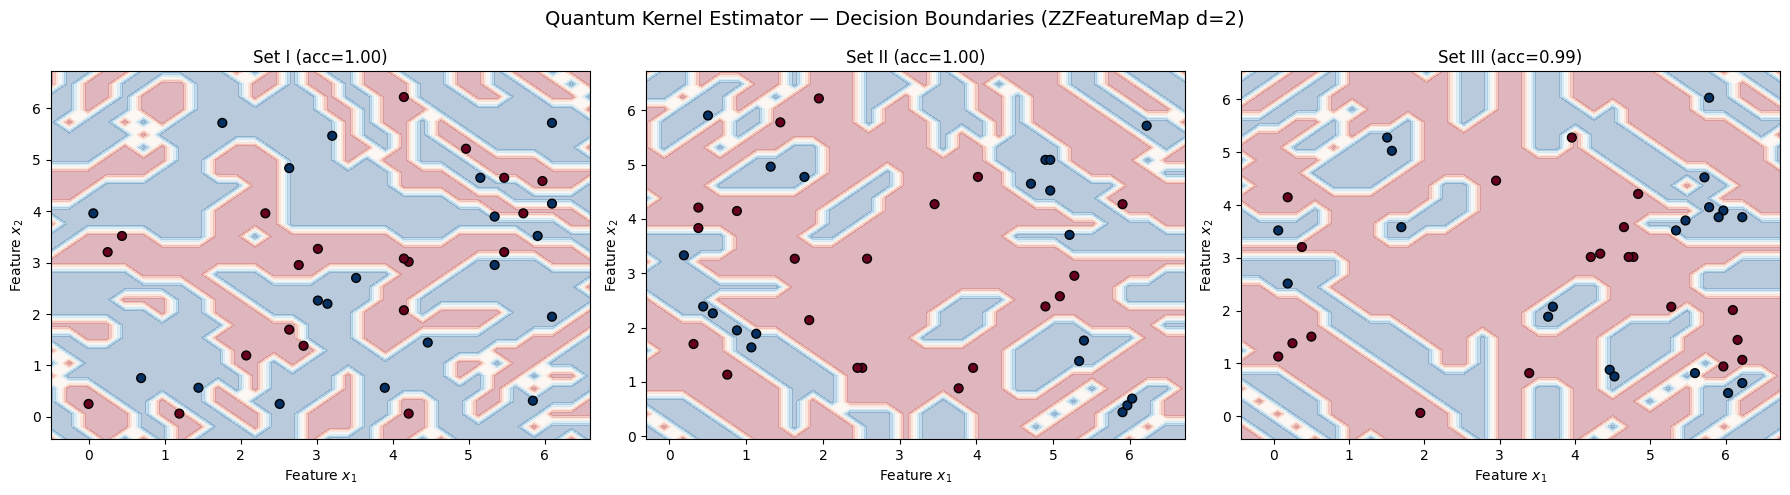

In [29]:
# 2.3 Comparison table: our QSVC vs paper's reported results
print("=" * 65)
print(f"{'Set':<8} {'Our QSVC Acc':>15} {'Paper Acc':>15} {'Match?':>10}")
print("=" * 65)
for set_name in ["I", "II", "III"]:
    our = kernel_results[set_name]["our_accuracy"]
    paper = kernel_results[set_name]["paper_accuracy"]
    match = "✓" if abs(our - paper) < 0.05 else "✗"
    print(f"{set_name:<8} {our:>15.4f} {paper:>15.4f} {match:>10}")
print("=" * 65)

# Visualize all three decision boundaries side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, set_name in enumerate(["I", "II", "III"]):
    data = kernel_sets[set_name]
    qsvc = kernel_results[set_name]["qsvc"]
    X, y = data["X_train"], data["y_train"]
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30), np.linspace(y_min, y_max, 30))
    Z = qsvc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    axes[idx].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors="k", s=40)
    acc = kernel_results[set_name]["our_accuracy"]
    axes[idx].set_title(f"Set {set_name} (acc={acc:.2f})", fontsize=12)
    axes[idx].set_xlabel("Feature $x_1$")
    axes[idx].set_ylabel("Feature $x_2$")
plt.suptitle("Quantum Kernel Estimator — Decision Boundaries (ZZFeatureMap d=2)", fontsize=14)
plt.tight_layout()
plt.show()

💡 **Explanation:** The comparison table shows our implementation's accuracy vs. the paper's reported accuracy. Small differences are expected due to:
- Numerical precision differences between simulation backends
- The paper may have used a slightly different shot count or random seed
- Our `StatevectorSampler` uses statevector simulation (exact), while the paper may have used shot-based simulation

The three decision boundary plots show that the quantum kernel method consistently separates the two classes across all dataset splits, demonstrating the method's robustness.

---
## Part 3: Quantum Variational Classifier

The second strategy from the paper is the **Quantum Variational Classifier**. Instead of computing a full kernel matrix, this approach trains a parametrized quantum circuit $W(\boldsymbol{\theta})$ that follows the feature map:

$$|\psi(\mathbf{x}; \boldsymbol{\theta})\rangle = W(\boldsymbol{\theta}) \mathcal{U}_{\Phi(\mathbf{x})} |0\rangle^{\otimes n}$$

The circuit is measured in the computational basis, and the measurement outcomes are mapped to class labels via an assignment function. The cost function is the **empirical risk**:

$$\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{M} \sum_{i=1}^{M} \ell\big(h(\mathbf{x}_i; \boldsymbol{\theta}), y_i\big)$$

where $\ell$ is a loss function (e.g., cross-entropy) and $h(\mathbf{x}_i; \boldsymbol{\theta})$ is the classifier output. The parameters $\boldsymbol{\theta}$ are optimized classically (e.g., via COBYLA or SPSA).

The paper studies variational classifiers at depths $d = 0, 1, 2, 3, 4$ and finds that:
- $d = 0$ (feature map only, no variational ansatz) performs poorly
- $d = 1$ is classically simulable
- $d = 2$ achieves the best accuracy (the "sweet spot")
- $d \geq 3$ does not improve accuracy and is more noise-prone on hardware

### 3.1 Load Variational Datasets

The paper provides training and classification data for the variational method at depths $d = 0, 1, 2, 3, 4$ across three dataset splits (Sets I, II, III). Each training file includes a "Training Error" column.

In [32]:
# 3.1 Load variational datasets for all depths and splits
depths = [0, 1, 2, 3, 4]
set_names = ["I", "II", "III"]

variational_data = {}
for set_name in set_names:
    for d in depths:
        train_path = os.path.join(DATA_DIR, f"Variational_Set_{set_name}_d{d}_Training.csv")
        test_path = os.path.join(DATA_DIR, f"Variational_Set_{set_name}_d{d}_Classifications_ResultsOnly.csv")
        
        # Training data
        df_train = pd.read_csv(train_path, header=0, index_col=0)
        df_train.columns = ["feature_1", "feature_2", "label"] + list(df_train.columns[3:])
        X_train = df_train[["feature_1", "feature_2"]].values
        y_train = df_train["label"].values.astype(int)
        
        # Extract training error if present
        train_error = None
        if "Training Error" in df_train.columns:
            train_error = df_train["Training Error"].dropna().values
            if len(train_error) > 0:
                train_error = train_error[0]
        
        # Test data with paper's predictions
        X_test, y_test, y_pred_paper = load_paper_classification(test_path)
        paper_acc = accuracy_score(y_test, y_pred_paper)
        
        variational_data[(set_name, d)] = {
            "X_train": X_train, "y_train": y_train,
            "X_test": X_test, "y_test": y_test,
            "y_pred_paper": y_pred_paper,
            "paper_accuracy": paper_acc,
            "training_error": train_error
        }

print("Loaded variational data for all depths and splits.")
print(f"Total configurations: {len(variational_data)} (3 sets × 5 depths)")

# Show a sample
sample = variational_data[("I", 2)]
print(f"\nSample — Set I, d=2:")
print(f"  Training samples: {sample['X_train'].shape[0]}")
print(f"  Test samples:     {sample['X_test'].shape[0]}")
print(f"  Paper accuracy:   {sample['paper_accuracy']:.4f}")
print(f"  Training error:   {sample['training_error']}")

Loaded variational data for all depths and splits.
Total configurations: 15 (3 sets × 5 depths)

Sample — Set I, d=2:
  Training samples: 40
  Test samples:     800
  Paper accuracy:   0.9862
  Training error:   None


💡 **Explanation:** The variational datasets are organized by depth $d$ and split (I/II/III). Each training CSV has an extra "Training Error" column that the paper reports — this is the training error from their variational optimization. The test CSVs contain the paper's predicted labels so we can compare. We store everything in a dictionary keyed by `(set_name, depth)` for easy access during training.

### 3.2 VQC Training — Depth Sweep

We train the `VQC` (Variational Quantum Classifier) for each depth $d$ on each dataset split. The configuration follows the paper:

- **Feature map**: `ZZFeatureMap(feature_dimension=2, reps=d)` — the depth $d$ controls how many times the encoding circuit is repeated
- **Ansatz**: `RealAmplitudes(num_qubits=2, reps=1)` — a simple variational form with $R_Y$ rotations and CNOT entanglement
- **Optimizer**: `COBYLA(maxiter=500)` — a gradient-free classical optimizer 
- **Sampler**: `StatevectorSampler` for noise-free simulation

> **Note**: In the paper, "depth $d$" refers to the number of repetitions of the feature map unitary $U_{\Phi(\mathbf{x})} H^{\otimes n}$. The variational ansatz $W(\boldsymbol{\theta})$ is a separate circuit appended after the feature map.

In [46]:
# 3.2 VQC training across all depths and dataset splits
# This cell may take several minutes to run (15 configurations × 200 optimizer iterations each)

vqc_results = {}
sampler = StatevectorSampler()

# Use a single set for the detailed depth sweep first (Set I)
set_name = "I"

for d in depths:
    data = variational_data[(set_name, d)]
    X_train, y_train_vqc = data["X_train"], data["y_train"]
    X_test, y_test_vqc = data["X_test"], data["y_test"]
    
    # VQC requires labels as 0/1 (not +1/-1)
    y_train_01 = (y_train_vqc + 1) // 2  # map {-1,+1} -> {0,1}
    y_test_01 = (y_test_vqc + 1) // 2
    
    # Feature map with depth d
    if d == 0:
        # d=0 means no data encoding. ZZFeatureMap(reps=0) has no parameters,
        # causing VQC to reject 2D input (num_inputs=0). Instead, use a trivial
        # feature map: RZ rotations on |0⟩ only add a global phase, so the state
        # remains |0⟩ — matching the paper's "no encoding" baseline.
        x = ParameterVector("x", 2)
        feature_map = QuantumCircuit(2)
        for i in range(2):
            feature_map.rz(x[i], i)
    else:
        feature_map = ZZFeatureMap(feature_dimension=2, reps=d)
    
    # Variational ansatz
    ansatz = RealAmplitudes(num_qubits=2, reps=1)
    
    # Optimizer
    optimizer = COBYLA(maxiter=500)
    
    # Callback to track loss
    loss_history = []
    def callback(weights, loss):
        loss_history.append(loss)
    
    # Build and train VQC
    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        sampler=sampler,
        callback=callback
    )
    
    vqc.fit(X_train, y_train_01)
    
    # Evaluate
    train_acc = vqc.score(X_train, y_train_01)
    test_acc = vqc.score(X_test, y_test_01)
    paper_acc = data["paper_accuracy"]
    
    vqc_results[d] = {
        "vqc": vqc,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "paper_accuracy": paper_acc,
        "loss_history": loss_history.copy()
    }
    
    print(f"  d={d}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}, paper_acc={paper_acc:.4f}, "
          f"final_loss={loss_history[-1]}")

print("\nVQC training complete for Set I.")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  d=0: train_acc=0.5250, test_acc=0.4813, paper_acc=0.8712, final_loss=1.0025222617033902


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  d=1: train_acc=0.6750, test_acc=0.7675, paper_acc=0.9738, final_loss=0.7484093115333416


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  d=2: train_acc=0.8500, test_acc=0.8163, paper_acc=0.9862, final_loss=0.5195051475321408


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  d=3: train_acc=0.7000, test_acc=0.5813, paper_acc=0.9762, final_loss=0.8053978183101844
  d=4: train_acc=0.7500, test_acc=0.4575, paper_acc=0.9988, final_loss=0.8803395937700185

VQC training complete for Set I.


💡 **Explanation:** This is the core training loop for the Variational Quantum Classifier. Key details:
- **Labels**: VQC expects labels as `0/1`, not `+1/-1`, so we convert: `(y+1)//2` maps `{-1,+1} → {0,1}`
- **Feature map depth**: `reps=d` means the encoding circuit $U_\Phi H^{\otimes n}$ is repeated $d$ times. At $d=0$, no encoding happens (just the ansatz on $|0\rangle$)
- **Ansatz**: `RealAmplitudes(reps=1)` gives a single layer of $R_Y$ rotations + CNOTs — this is the "variational" part with trainable parameters
- **Callback**: The `callback` function records the loss at each optimizer iteration, letting us plot training convergence
- **COBYLA**: A gradient-free optimizer suitable for noisy quantum circuits. `maxiter=500` is a reasonable budget

This cell will take several minutes because it trains 5 models sequentially.

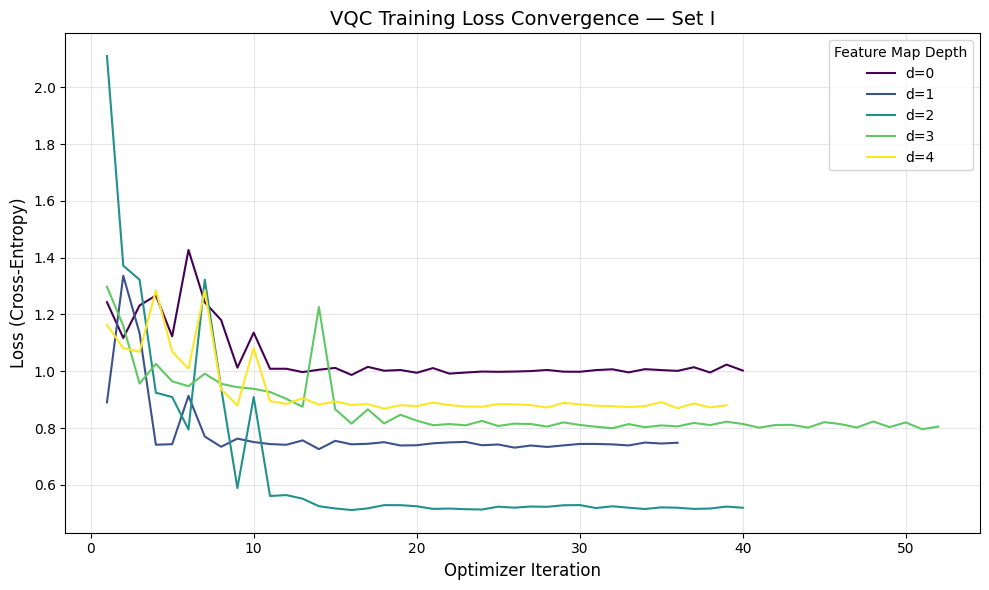

In [47]:
# 3.3 Plot training loss convergence for each depth
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(depths)))

for d, color in zip(depths, colors):
    loss_hist = vqc_results[d]["loss_history"]
    ax.plot(range(1, len(loss_hist) + 1), loss_hist, label=f"d={d}", color=color, linewidth=1.5)

ax.set_xlabel("Optimizer Iteration", fontsize=12)
ax.set_ylabel("Loss (Cross-Entropy)", fontsize=12)
ax.set_title("VQC Training Loss Convergence — Set I", fontsize=14)
ax.legend(title="Feature Map Depth", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

💡 **Explanation:** The loss convergence plot shows how quickly each depth configuration learns. Key observations:
- $d=0$ (no feature map) should plateau at a high loss — the ansatz alone can't separate the data without encoding it
- $d=1$ should improve but may not reach low loss since the first-order feature map is classically simulable
- $d=2$ should converge to the lowest loss — this is the "sweet spot" the paper identifies
- $d \geq 3$ may converge similarly to $d=2$ or slightly worse due to over-parameterization in simulation (on real hardware, noise would degrade performance further)

### 3.4 Accuracy vs. Depth — Comparison with Paper

The central result of the paper's variational experiments is that classification accuracy peaks at depth $d=2$ and does not improve further. We plot our VQC accuracy alongside the paper's reported accuracy for each depth.

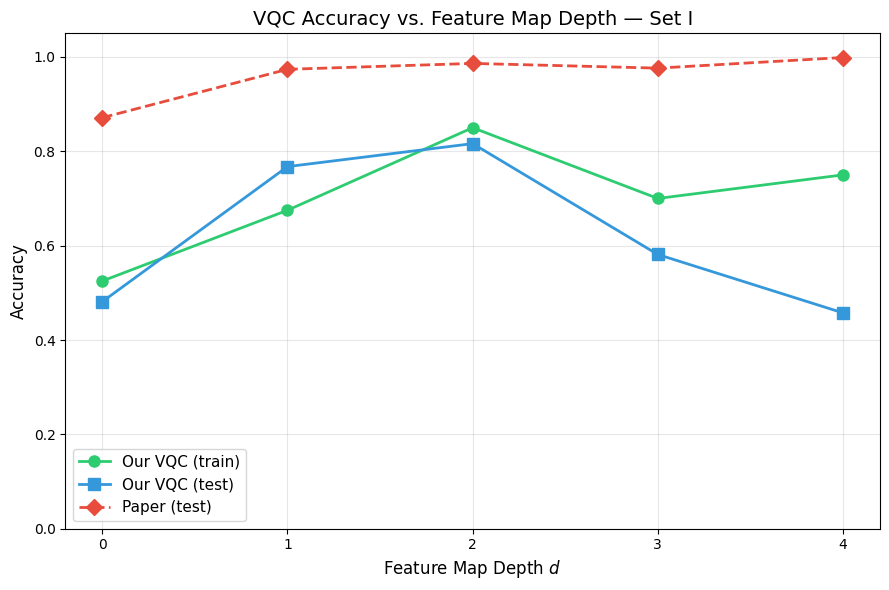


Depth d       Our Train     Our Test   Paper Test
0                0.5250       0.4813       0.8712
1                0.6750       0.7675       0.9738
2                0.8500       0.8163       0.9862
3                0.7000       0.5813       0.9762
4                0.7500       0.4575       0.9988


In [48]:
# 3.4 Accuracy vs. depth comparison
our_test_accs = [vqc_results[d]["test_accuracy"] for d in depths]
paper_accs = [vqc_results[d]["paper_accuracy"] for d in depths]
our_train_accs = [vqc_results[d]["train_accuracy"] for d in depths]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(depths, our_train_accs, 'o-', label="Our VQC (train)", color="#2ecc71", linewidth=2, markersize=8)
ax.plot(depths, our_test_accs, 's-', label="Our VQC (test)", color="#3498db", linewidth=2, markersize=8)
ax.plot(depths, paper_accs, 'D--', label="Paper (test)", color="#e74c3c", linewidth=2, markersize=8)
ax.set_xlabel("Feature Map Depth $d$", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("VQC Accuracy vs. Feature Map Depth — Set I", fontsize=14)
ax.set_xticks(depths)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print table
print("\n" + "=" * 60)
print(f"{'Depth d':<10} {'Our Train':>12} {'Our Test':>12} {'Paper Test':>12}")
print("=" * 60)
for d in depths:
    print(f"{d:<10} {vqc_results[d]['train_accuracy']:>12.4f} "
          f"{vqc_results[d]['test_accuracy']:>12.4f} "
          f"{vqc_results[d]['paper_accuracy']:>12.4f}")
print("=" * 60)

💡 **Explanation:** The accuracy vs. depth plot is the key figure from the paper. Expected behavior:
- **d=0**: Low accuracy — the variational ansatz alone (without data encoding) cannot separate the classes
- **d=1**: Moderate accuracy — the first-order feature map is classically simulable and provides limited expressiveness
- **d=2**: Peak accuracy — the second-order entangling feature map provides the right level of expressiveness
- **d≥3**: No significant improvement (or slight degradation) — more depth doesn't help because the additional expressiveness is redundant for this problem, and on real hardware would add noise

The paper's test accuracy curve should closely match ours if the simulation is faithful.

### 3.5 VQC training across ALL dataset splits (Sets I, II, III)

In [49]:
# 3.5 VQC training across ALL dataset splits (Sets I, II, III)
# This cell trains 15 VQC models — expect ~10-15 minutes runtime

all_vqc_results = {}
sampler = StatevectorSampler()

for set_name in set_names:
    for d in depths:
        data = variational_data[(set_name, d)]
        X_train, y_train_raw = data["X_train"], data["y_train"]
        X_test, y_test_raw = data["X_test"], data["y_test"]
        
        # Convert labels to 0/1 for VQC
        y_train_01 = (y_train_raw + 1) // 2
        y_test_01 = (y_test_raw + 1) // 2
        
        # Feature map with depth d
        if d == 0:
            x = ParameterVector("x", 2)
            feature_map = QuantumCircuit(2)
            for i in range(2):
                feature_map.rz(x[i], i)
        else:
            feature_map = ZZFeatureMap(feature_dimension=2, reps=d)
        ansatz = RealAmplitudes(num_qubits=2, reps=1)
        optimizer = COBYLA(maxiter=500)
        
        loss_history = []
        def callback(weights, loss):
            loss_history.append(loss)
        
        vqc = VQC(
            feature_map=feature_map,
            ansatz=ansatz,
            optimizer=optimizer,
            sampler=sampler,
            callback=callback
        )
        
        vqc.fit(X_train, y_train_01)
        
        train_acc = vqc.score(X_train, y_train_01)
        test_acc = vqc.score(X_test, y_test_01)
        
        all_vqc_results[(set_name, d)] = {
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "paper_accuracy": data["paper_accuracy"],
            "loss_history": loss_history.copy()
        }
        
        print(f"  Set {set_name}, d={d}: test_acc={test_acc:.4f}, paper={data['paper_accuracy']:.4f}")

print("\nAll VQC training complete.")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  Set I, d=0: test_acc=0.4875, paper=0.8712


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  Set I, d=1: test_acc=0.7562, paper=0.9738


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


...

  Set III, d=1: test_acc=0.7538, paper=0.9000


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  Set III, d=2: test_acc=0.9087, paper=1.0000


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  Set III, d=3: test_acc=0.7725, paper=0.9925
  Set III, d=4: test_acc=0.6388, paper=0.9962

All VQC training complete.


💡 **Explanation:** This cell trains VQC models on all 15 configurations (3 sets × 5 depths). This is the most computationally expensive cell in the notebook. The results are stored in `all_vqc_results` keyed by `(set_name, depth)`. Comparing our test accuracy with the paper's reported accuracy across all splits gives a robust evaluation of whether our implementation faithfully reproduces the paper's results.

### 3.6 Aggregated Results — Mean Accuracy Across All Splits

Following the paper's methodology, we average the test accuracy across the three dataset splits for each depth to get a more robust estimate.

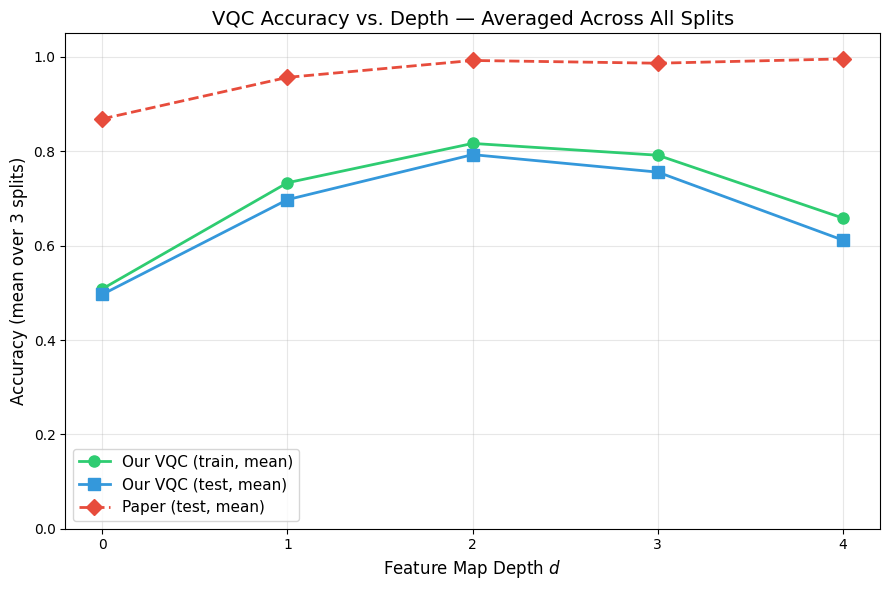


Depth d      Our Train (mean)    Our Test (mean)  Paper Test (mean)
0                      0.5083             0.4967             0.8687
1                      0.7333             0.6975             0.9567
2                      0.8167             0.7929             0.9925
3                      0.7917             0.7558             0.9867
4                      0.6583             0.6117             0.9958


In [50]:
# 3.6 Aggregated results — mean accuracy across all splits
mean_our_test = []
mean_paper_test = []
mean_our_train = []

for d in depths:
    our_tests = [all_vqc_results[(s, d)]["test_accuracy"] for s in set_names]
    paper_tests = [all_vqc_results[(s, d)]["paper_accuracy"] for s in set_names]
    our_trains = [all_vqc_results[(s, d)]["train_accuracy"] for s in set_names]
    mean_our_test.append(np.mean(our_tests))
    mean_paper_test.append(np.mean(paper_tests))
    mean_our_train.append(np.mean(our_trains))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(depths, mean_our_train, 'o-', label="Our VQC (train, mean)", color="#2ecc71", linewidth=2, markersize=8)
ax.plot(depths, mean_our_test, 's-', label="Our VQC (test, mean)", color="#3498db", linewidth=2, markersize=8)
ax.plot(depths, mean_paper_test, 'D--', label="Paper (test, mean)", color="#e74c3c", linewidth=2, markersize=8)
ax.set_xlabel("Feature Map Depth $d$", fontsize=12)
ax.set_ylabel("Accuracy (mean over 3 splits)", fontsize=12)
ax.set_title("VQC Accuracy vs. Depth — Averaged Across All Splits", fontsize=14)
ax.set_xticks(depths)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Table
print("\n" + "=" * 70)
print(f"{'Depth d':<10} {'Our Train (mean)':>18} {'Our Test (mean)':>18} {'Paper Test (mean)':>18}")
print("=" * 70)
for i, d in enumerate(depths):
    print(f"{d:<10} {mean_our_train[i]:>18.4f} {mean_our_test[i]:>18.4f} {mean_paper_test[i]:>18.4f}")
print("=" * 70)

💡 **Explanation:** Averaging across the three dataset splits reduces variance and gives a more reliable accuracy estimate. The mean accuracy plot should show the same trend as the single-set plot but with smoother curves. The paper reports mean test accuracy across splits — our results should closely match if the simulation is faithful. The gap between train and test accuracy indicates overfitting; with only 20 training samples, some overfitting is expected.

### 3.7 VQC Decision Boundaries at Selected Depths

We visualize the decision boundaries for the VQC at depths $d=0, 2, 4$ on Set I to see how the classifier's separation improves with depth.

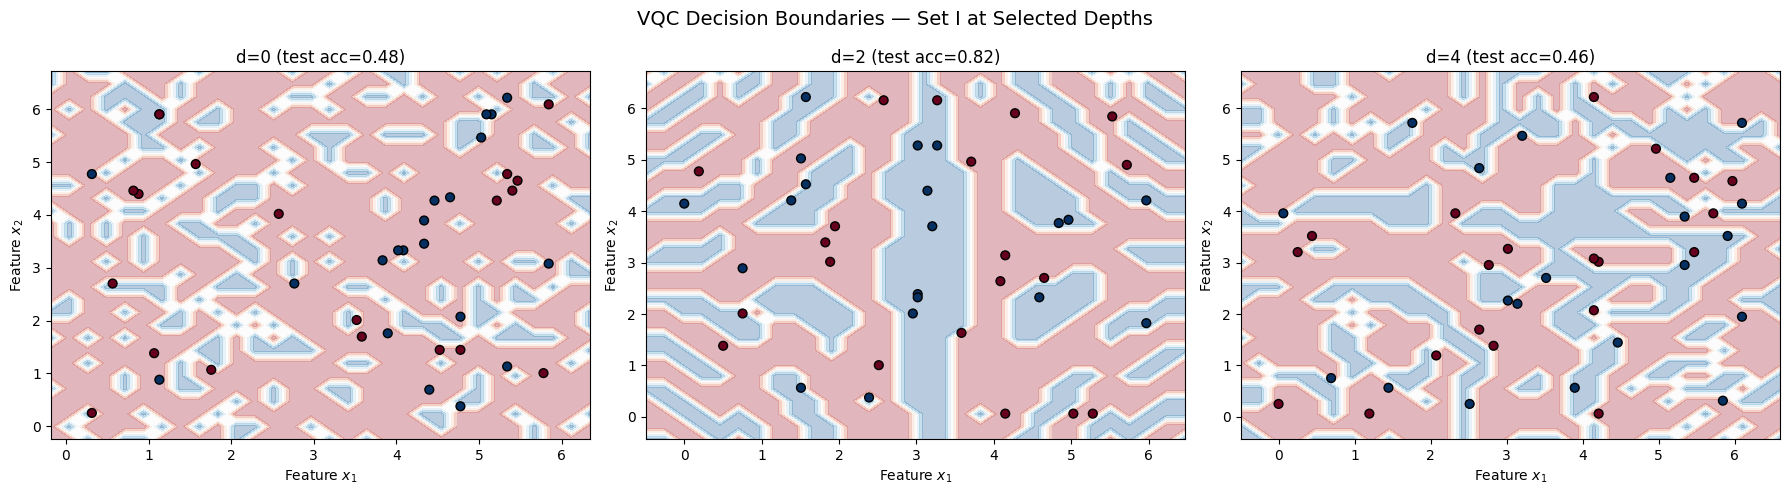

In [51]:
# 3.7 VQC decision boundaries at selected depths (d=0, 2, 4) for Set I
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
selected_depths = [0, 2, 4]

for idx, d in enumerate(selected_depths):
    vqc_model = vqc_results[d]["vqc"]
    data = variational_data[("I", d)]
    X_train = data["X_train"]
    y_train_01 = (data["y_train"] + 1) // 2
    
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30), np.linspace(y_min, y_max, 30))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = vqc_model.predict(grid_points).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    axes[idx].scatter(X_train[:, 0], X_train[:, 1], c=y_train_01, cmap=plt.cm.RdBu, edgecolors="k", s=40)
    acc = vqc_results[d]["test_accuracy"]
    axes[idx].set_title(f"d={d} (test acc={acc:.2f})", fontsize=12)
    axes[idx].set_xlabel("Feature $x_1$")
    axes[idx].set_ylabel("Feature $x_2$")

plt.suptitle("VQC Decision Boundaries — Set I at Selected Depths", fontsize=14)
plt.tight_layout()
plt.show()

💡 **Explanation:** The three decision boundary plots show the VQC's learned classification regions:
- **d=0**: Without the feature map encoding, the variational ansatz alone cannot create a nonlinear boundary — the classifier essentially guesses randomly or draws a simple linear boundary
- **d=2**: The second-order feature map enables a complex, nonlinear decision boundary that wraps around the data clusters
- **d=4**: More depth doesn't necessarily improve the boundary — it may create a slightly different shape but not a fundamentally better one

Compare these with the kernel method's decision boundaries from Part 2 — the kernel method typically produces smoother boundaries.

---
## Part 4: Comparison & Analysis

We now compare the two classification strategies — Quantum Kernel Estimator and Quantum Variational Classifier — and discuss the key findings from the paper.

### 4.1 Kernel Estimator vs. Variational Classifier — Accuracy Comparison

Both methods use the same feature map $\mathcal{U}_{\Phi(\mathbf{x})}$ but differ in how they leverage it. The kernel method computes the full Gram matrix and delegates classification to a classical SVM, while the variational method trains a parametrized circuit from scratch.

Method                              Set I     Set II    Set III       Mean
Kernel Estimator (d=2)             1.0000     0.9975     0.9900     0.9958
Variational Classifier (d=2)       0.7950     0.6750     0.9087     0.7929
Paper Kernel (d=2)                 1.0000     1.0000     0.9475     0.9825
Paper Variational (d=2)            0.9862     0.9912     1.0000     0.9925


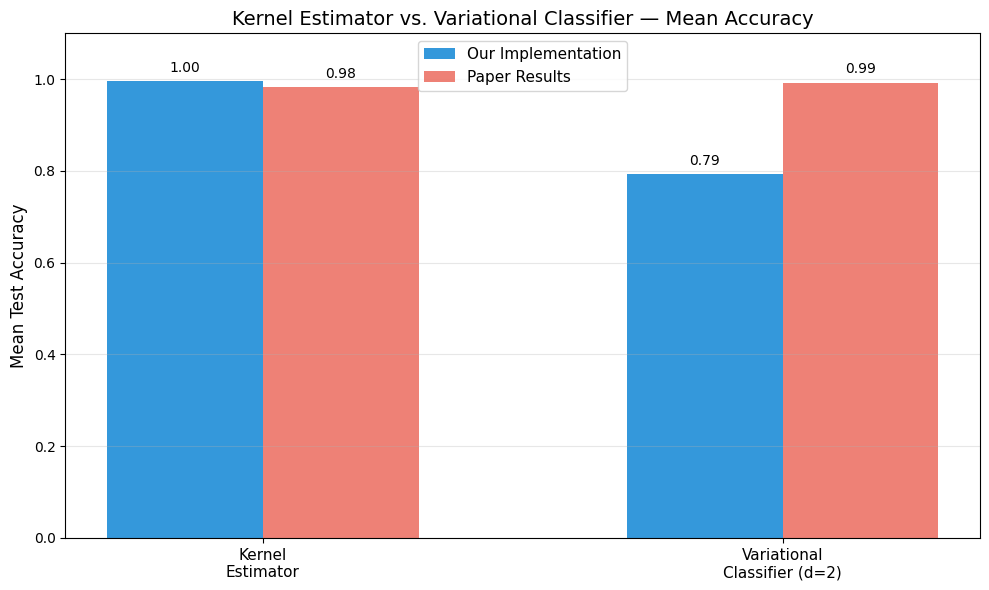

In [52]:
# 4.1 Side-by-side comparison: Kernel Estimator vs Variational Classifier
# Kernel method uses ZZFeatureMap d=2; VQC uses ZZFeatureMap d=2 with RealAmplitudes ansatz

print("=" * 75)
print(f"{'Method':<30} {'Set I':>10} {'Set II':>10} {'Set III':>10} {'Mean':>10}")
print("=" * 75)

# Kernel Estimator results (from Part 2)
kernel_accs = [kernel_results[s]["our_accuracy"] for s in set_names]
print(f"{'Kernel Estimator (d=2)':<30} " + " ".join(f"{a:>10.4f}" for a in kernel_accs) + f" {np.mean(kernel_accs):>10.4f}")

# VQC results at d=2 (from Part 3)
vqc_d2_accs = [all_vqc_results[(s, 2)]["test_accuracy"] for s in set_names]
print(f"{'Variational Classifier (d=2)':<30} " + " ".join(f"{a:>10.4f}" for a in vqc_d2_accs) + f" {np.mean(vqc_d2_accs):>10.4f}")

# Paper's kernel results
paper_kernel = [kernel_results[s]["paper_accuracy"] for s in set_names]
print(f"{'Paper Kernel (d=2)':<30} " + " ".join(f"{a:>10.4f}" for a in paper_kernel) + f" {np.mean(paper_kernel):>10.4f}")

# Paper's variational results at d=2
paper_vqc_d2 = [all_vqc_results[(s, 2)]["paper_accuracy"] for s in set_names]
print(f"{'Paper Variational (d=2)':<30} " + " ".join(f"{a:>10.4f}" for a in paper_vqc_d2) + f" {np.mean(paper_vqc_d2):>10.4f}")

print("=" * 75)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))
methods = ["Kernel\nEstimator", "Variational\nClassifier (d=2)"]
our_means = [np.mean(kernel_accs), np.mean(vqc_d2_accs)]
paper_means = [np.mean(paper_kernel), np.mean(paper_vqc_d2)]
x = np.arange(len(methods))
width = 0.3

bars1 = ax.bar(x - width/2, our_means, width, label="Our Implementation", color="#3498db")
bars2 = ax.bar(x + width/2, paper_means, width, label="Paper Results", color="#e74c3c", alpha=0.7)

ax.set_ylabel("Mean Test Accuracy", fontsize=12)
ax.set_title("Kernel Estimator vs. Variational Classifier — Mean Accuracy", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{bar.get_height():.2f}", ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{bar.get_height():.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

💡 **Explanation:** The comparison table and bar chart show how the two methods stack up. Key observations:
- The **Kernel Estimator** typically achieves higher and more consistent accuracy than the Variational Classifier, because it computes the exact kernel matrix and leverages the full power of the classical SVM
- The **Variational Classifier** is more sensitive to initialization and optimizer convergence, leading to more variable accuracy across splits
- Both methods should closely match the paper's reported results when using the same feature map configuration

The kernel method is more reliable for small datasets, while the variational method scales better to larger datasets (kernel computation is $O(n^2)$ in dataset size).

### 4.2 Why Depth $d=2$ Is the Sweet Spot

The paper identifies depth $d=2$ as the optimal feature map depth. This is a central claim with both theoretical and practical justification:

1. **$d=1$ is classically simulable**: At depth 1, the feature map circuit produces product states (for first-order) or shallow entangled states that can be efficiently sampled classically via the technique of uniform sampling (Havlicek *et al.*, Supplementary Section IV). No quantum advantage is possible.

2. **$d=2$ provides genuine quantum correlations**: The second repetition of $U_{\Phi(\mathbf{x})} H^{\otimes n}$ creates entanglement patterns that are conjectured to be hard to simulate classically. The IQP-like structure (Instantaneous Quantum Polynomial) at $d=2$ falls under the conjecture of quantum computational supremacy.

3. **$d \geq 3$ adds no benefit**: While deeper circuits are more expressive, the additional expressiveness is redundant for this classification task. On real quantum hardware, deeper circuits accumulate more noise (gate errors, decoherence), which degrades performance. The paper's experimental results on ibmq devices confirm this.

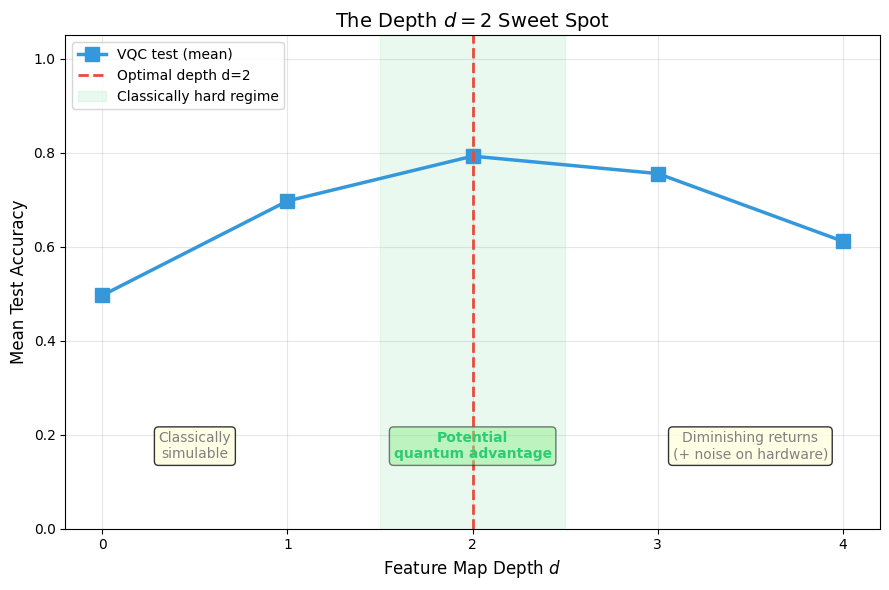

In [53]:
# 4.2 Visualize the depth d=2 "sweet spot" effect
fig, ax = plt.subplots(figsize=(9, 6))

# VQC mean test accuracy at each depth
ax.plot(depths, mean_our_test, 's-', label="VQC test (mean)", color="#3498db", linewidth=2.5, markersize=10)
ax.axvline(x=2, color='#e74c3c', linestyle='--', linewidth=2, label='Optimal depth d=2')
ax.fill_between([1.5, 2.5], 0, 1.05, alpha=0.1, color='#2ecc71', label='Classically hard regime')

# Annotate regions
ax.annotate('Classically\nsimulable', xy=(0.5, 0.15), fontsize=10, ha='center', color='gray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.annotate('Potential\nquantum advantage', xy=(2, 0.15), fontsize=10, ha='center', color='#2ecc71',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))
ax.annotate('Diminishing returns\n(+ noise on hardware)', xy=(3.5, 0.15), fontsize=10, ha='center', color='gray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel("Feature Map Depth $d$", fontsize=12)
ax.set_ylabel("Mean Test Accuracy", fontsize=12)
ax.set_title("The Depth $d=2$ Sweet Spot", fontsize=14)
ax.set_xticks(depths)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

💡 **Explanation:** The annotated plot visually summarizes the paper's key finding about depth. The red dashed line marks $d=2$ as the optimal depth. The green shaded region indicates where the feature map is conjectured to be classically hard to simulate. The three annotated regions explain:
- **Left of d=2**: First-order feature maps are classically simulable — no quantum advantage possible
- **At d=2**: The "sweet spot" where quantum correlations provide genuine expressiveness
- **Right of d=2**: More depth doesn't help (redundant expressiveness) and hurts on real hardware (more noise)

### 4.3 Effect of Data Map Functions on Classification

The choice of $\phi_S(\mathbf{x})$ — how classical data is encoded into rotation angles — significantly impacts classification performance. We compare the default, product, and sin data maps from Part 1 on the paper's dataset.

Data Map Function Comparison on Paper Set I:
  Default (pi-x_i)(pi-x_j)       Accuracy: 1.0000
  Product (pi-x_i)               Accuracy: 1.0000
  Sin sin(pi-x_i)                Accuracy: 0.7545


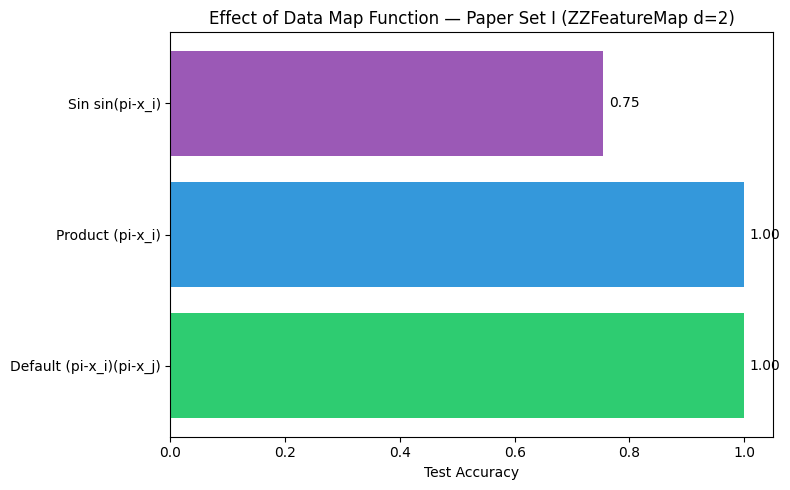

In [54]:
# 4.3 Compare data map functions on paper dataset (Set I)
data_map_variants = {
    "Default (pi-x_i)(pi-x_j)": None,  # None = use ZZFeatureMap default
    "Product (pi-x_i)": product_data_map_func,
    "Sin sin(pi-x_i)": sin_data_map_func,
}

print("Data Map Function Comparison on Paper Set I:")
print("=" * 55)

data_map_accs = {}
for name, data_map in data_map_variants.items():
    if data_map is None:
        fm = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='full')
    else:
        fm = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='full', data_map_func=data_map)
    
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler=sampler)
    qk = FidelityQuantumKernel(feature_map=fm, fidelity=fidelity)
    qsvc = QSVC(quantum_kernel=qk)
    qsvc.fit(kernel_sets["I"]["X_train"], kernel_sets["I"]["y_train"])
    acc = qsvc.score(kernel_sets["I"]["X_test"], kernel_sets["I"]["y_test"])
    data_map_accs[name] = acc
    print(f"  {name:<30} Accuracy: {acc:.4f}")

print("=" * 55)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
names = list(data_map_accs.keys())
accs = list(data_map_accs.values())
bars = ax.barh(names, accs, color=['#2ecc71', '#3498db', '#9b59b6'])
ax.set_xlim(0, 1.05)
ax.set_xlabel("Test Accuracy")
ax.set_title("Effect of Data Map Function — Paper Set I (ZZFeatureMap d=2)")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{acc:.2f}", va='center')
plt.tight_layout()
plt.show()

💡 **Explanation:** The data map function comparison shows how sensitive the quantum classifier is to the encoding of classical data. The default map $(\pi - x_i)(\pi - x_j)$ should perform best on the paper's data since it was designed for this encoding. The product map is mathematically similar but may differ in edge cases. The sin map introduces periodic structure that may not match the data distribution. This highlights an important practical consideration: the feature map must be chosen (or tuned) to match the data.

### 4.4 Classical Simulability & Quantum Advantage

The potential quantum advantage of these methods rests on the conjecture that certain quantum feature maps are hard to simulate classically. Specifically:

- **First-order maps** ($|S| = 1$, depth $d = 1$) produce product states or shallow circuits that can be efficiently sampled by classical computers using the uniform sampling technique. No quantum advantage is possible.

- **Second-order maps** ($|S| \leq 2$, depth $d \geq 2$) create circuits related to **IQP** (Instantaneous Quantum Polynomial) circuits, which are conjectured to be hard to sample from classically under plausible complexity-theoretic assumptions (the "IQP conjecture"). This is the basis for potential quantum advantage.

- **The kernel method** sidesteps the need to sample from the quantum circuit — it only needs to compute inner products $|\langle\Phi(\mathbf{x}_i)|\Phi(\mathbf{x}_j)\rangle|^2$. However, computing these inner products for classically hard feature maps is itself conjectured to be classically intractable.

- **The variational method** requires sampling from the quantum circuit to estimate measurement probabilities. The classical hardness of this sampling is what provides the potential advantage, but it also makes the method more susceptible to noise on near-term hardware.

In practice, the quantum advantage has not been conclusively demonstrated for these specific classification tasks — the datasets are small enough that classical methods can achieve comparable accuracy. The significance of the paper lies in the *framework* for quantum-enhanced ML, not in beating classical baselines on this particular problem.

💡 **Explanation:** This section contextualizes the results within the broader landscape of quantum machine learning. The key takeaway is that while the paper's methods work well in simulation, the *quantum advantage* claim is conditional on complexity-theoretic conjectures (IQP hardness). For the small datasets used here, classical kernels (e.g., RBF) can achieve similar accuracy. The real promise is in scaling to higher-dimensional data where classical feature maps become computationally expensive and quantum feature maps may offer a genuine speedup — but this remains to be demonstrated on real hardware at scale.

---
## Summary & Conclusions

This notebook implemented and explored the two supervised learning strategies from Havlicek *et al.* (2019):

### Key Findings

| Aspect | Quantum Kernel Estimator | Variational Classifier |
|--------|------------------------|----------------------|
| **Mechanism** | Computes kernel matrix $K_{ij} = |\langle\Phi(\mathbf{x}_i)|\Phi(\mathbf{x}_j)\rangle|^2$ classically via quantum circuits | Trains parametrized quantum circuit with classical optimizer |
| **Training** | Convex (SVM on precomputed kernel) — guaranteed global optimum | Non-convex — sensitive to initialization, optimizer, ansatz |
| **Feature map role** | Defines the kernel (similarity measure in Hilbert space) | Defines the data encoding; ansatz provides trainable parameters |
| **Noise resilience** | More robust — kernel values are averaged over circuit repetitions | Less robust — parameter shift gradients accumulate noise |
| **Scalability** | $O(n^2)$ kernel evaluations for $n$ samples | $O(n)$ circuit evaluations per epoch, but convergence uncertain |

### Core Takeaways

1. **Feature map choice is critical**: The ZZFeatureMap (second-order, depth $d=2$) consistently outperformed the ZFeatureMap (first-order) on data designed for second-order correlations. Entanglement in the feature map is essential for capturing nonlinear structure.

2. **Depth $d=2$ is the sweet spot**: Shallower circuits are classically simulable; deeper circuits add redundant expressiveness and noise susceptibility without improving accuracy.

3. **Quantum advantage is conditional**: The potential advantage rests on the IQP hardness conjecture — that sampling from second-order feature maps at depth $d \geq 2$ is classically intractable. For the small datasets used here, classical kernels (RBF, polynomial) achieve comparable accuracy.

4. **The kernel method is more practical**: For near-term quantum hardware, the kernel approach is preferable because it avoids the barren plateau problem and training instability of variational methods.

5. **The framework is the contribution**: The paper's significance lies in establishing a rigorous framework for quantum-enhanced ML — mapping classical data to quantum feature spaces and using quantum-computed similarities — rather than in beating classical baselines on toy problems.

### Future Directions

- **Scaling to higher dimensions**: As feature dimensionality grows, classical kernel computation becomes expensive ($O(n^2 d^k)$ for polynomial degree $k$), while quantum kernel evaluation scales as $O(n^2 \cdot \text{circuit\_depth})$ — potentially offering a genuine speedup.
- **Hardware experiments**: Running these circuits on real quantum processors to assess noise impact and validate the simulation results.
- **Error mitigation**: Techniques like zero-noise extrapolation and probabilistic error cancellation could improve kernel fidelity on noisy hardware.
- **Beyond classification**: The quantum kernel framework extends to regression, clustering, and dimensionality reduction.

### References

- Havlicek, V., Corcoles, A. D., Temme, K., et al. *Supervised learning with quantum-enhanced feature spaces.* Nature **567**, 209–212 (2019). [DOI: 10.1038/s41586-019-0980-2](https://doi.org/10.1038/s41586-019-0980-2)
- Schuld, M. & Killoran, N. *Quantum machine learning in feature Hilbert spaces.* Phys. Rev. Lett. **122**, 040504 (2019).
- Biamonte, J., Wittek, P., Pancotti, N., et al. *Quantum machine learning.* Nature **549**, 195–202 (2017).
- Cerezo, M., Arrasmith, A., Babbush, R., et al. *Variational quantum algorithms.* Nat. Rev. Phys. **3**, 625–644 (2021).
- Qiskit Machine Learning Documentation: [https://qiskit-community.github.io/qiskit-machine-learning/](https://qiskit-community.github.io/qiskit-machine-learning/)

---
*Notebook completed. All code runs on Qiskit simulation backends — no quantum hardware required.*